In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import albumentations as A
from skimage.transform import resize
import scipy.ndimage as ndimage

/usr/local/lib/python3.11/dist-packages/albumentations/check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [2]:
# Data Preprocessing Functions
# =====================
def resample_volume(image, original_spacing, target_spacing=(1.0, 1.0, 1.0)):
    resize_factor = np.array(original_spacing) / np.array(target_spacing)
    return ndimage.zoom(image, resize_factor, order=1)

def normalize_hu(volume, min_hu=-100, max_hu=200):
    volume = np.clip(volume, min_hu, max_hu)
    volume = (volume - min_hu) / (max_hu - min_hu)
    return volume

def resize_volume(volume, target_shape=(64, 64, 64)):
    return resize(volume, target_shape, order=1, preserve_range=True)

def get_augmentation():
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.3),
        A.GridDistortion(p=0.3),
    ])

def process_volume(ct_path, mask_path=None, target_shape=(64, 64, 64), apply_aug=False):
    ct_nib = nib.load(ct_path)
    ct_volume = ct_nib.get_fdata()
    original_spacing = ct_nib.header.get_zooms()
    ct_volume = resample_volume(ct_volume, original_spacing)
    ct_volume = normalize_hu(ct_volume)
    ct_volume = resize_volume(ct_volume, target_shape)
    if mask_path:
        mask_nib = nib.load(mask_path)
        mask_volume = mask_nib.get_fdata()
        mask_volume = resample_volume(mask_volume, original_spacing)
        mask_volume = resize_volume(mask_volume, target_shape)
        mask_volume = (mask_volume > 0).astype(np.float32)
        if apply_aug:
            aug = get_augmentation()
            for z in range(ct_volume.shape[2]):
                augmented = aug(image=ct_volume[:,:,z], mask=mask_volume[:,:,z])
                ct_volume[:,:,z] = augmented['image']
                mask_volume[:,:,z] = augmented['mask']
        return ct_volume, mask_volume
    return ct_volume

In [3]:
# Dataset Class
# =====================
class LiverTumor2DSliceDataset(Dataset):
    def __init__(self, ct_paths, mask_paths, target_shape=(64, 64, 64), apply_aug=False):
        self.slices = []
        for ct_path, mask_path in zip(ct_paths, mask_paths):
            ct, mask = process_volume(ct_path, mask_path, target_shape, apply_aug)
            for z in range(ct.shape[2]):
                ct_slice = ct[:, :, z]
                mask_slice = mask[:, :, z]
                self.slices.append((ct_slice, mask_slice))
    def __len__(self):
        return len(self.slices)
    def __getitem__(self, idx):
        ct_slice, mask_slice = self.slices[idx]
        ct_slice = torch.from_numpy(ct_slice).float().unsqueeze(0)
        mask_slice = torch.from_numpy(mask_slice).float().unsqueeze(0)
        return ct_slice, mask_slice

In [4]:
# Model Definition
# =====================
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class AttentionUNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=2):
        super().__init__()
        self.maxpool = nn.MaxPool2d(2)
        self.down1 = ConvBlock(in_ch, 64)
        self.down2 = ConvBlock(64, 128)
        self.down3 = ConvBlock(128, 256)
        self.down4 = ConvBlock(256, 512)
        self.center = ConvBlock(512, 1024)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att4 = AttentionBlock(F_g=512, F_l=512, F_int=256)
        self.upconv4 = ConvBlock(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att3 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.upconv3 = ConvBlock(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att2 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.upconv2 = ConvBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.upconv1 = ConvBlock(128, 64)
        self.final = nn.Conv2d(64, out_ch, 1)
    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.maxpool(d1))
        d3 = self.down3(self.maxpool(d2))
        d4 = self.down4(self.maxpool(d3))
        center = self.center(self.maxpool(d4))
        up4 = self.up4(center)
        att4 = self.att4(g=up4, x=d4)
        up4 = self.upconv4(torch.cat([att4, up4], dim=1))
        up3 = self.up3(up4)
        att3 = self.att3(g=up3, x=d3)
        up3 = self.upconv3(torch.cat([att3, up3], dim=1))
        up2 = self.up2(up3)
        att2 = self.att2(g=up2, x=d2)
        up2 = self.upconv2(torch.cat([att2, up2], dim=1))
        up1 = self.up1(up2)
        att1 = self.att1(g=up1, x=d1)
        up1 = self.upconv1(torch.cat([att1, up1], dim=1))
        out = self.final(up1)
        return out

In [5]:
# Loss Functions
# =====================
bce_loss = nn.BCEWithLogitsLoss()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.contiguous()
        targets = targets.contiguous()
        intersection = (preds * targets).sum(dim=(2, 3))
        union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1 - dice_score
        return dice_loss.mean()

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

class ComboLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super(ComboLoss, self).__init__()
        self.alpha = alpha
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, preds, targets):
        bce = self.bce(preds, targets)
        dice = self.dice(preds, targets)
        return self.alpha * bce + (1 - self.alpha) * dice


In [6]:
# Evaluation/Metric Functions
# =====================
def dice_coefficient(preds, targets, threshold=0.5, eps=1e-7):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    targets = (targets > threshold).float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2. * intersection + eps) / (union + eps)
    return dice.mean().item()

def iou_score(preds, targets, threshold=0.5, eps=1e-7):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    targets = (targets > threshold).float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

def sensitivity(preds, targets, threshold=0.5, eps=1e-7):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    targets = (targets > threshold).float()
    tp = (preds * targets).sum(dim=(2, 3))
    fn = ((1 - preds) * targets).sum(dim=(2, 3))
    sens = (tp + eps) / (tp + fn + eps)
    return sens.mean().item()

def specificity(preds, targets, threshold=0.5, eps=1e-7):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    targets = (targets > threshold).float()
    tn = ((1 - preds) * (1 - targets)).sum(dim=(2, 3))
    fp = (preds * (1 - targets)).sum(dim=(2, 3))
    spec = (tn + eps) / (tn + fp + eps)
    return spec.mean().item()

In [7]:
# Data Paths and Split
# =====================
ct_dir = "/kaggle/input/litstrain-val/LiTS(train_test)/train_CT"
mask_dir = "/kaggle/input/litstrain-val/LiTS(train_test)/train_mask"
ct_paths = sorted(glob.glob(os.path.join(ct_dir, "*.nii")))
mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.nii")))
print(f"Found {len(ct_paths)} CT images and {len(mask_paths)} masks")

# Split into train/val (no separate val set in dataset)
train_ct_paths, val_ct_paths, train_mask_paths, val_mask_paths = train_test_split(
    ct_paths, mask_paths, test_size=0.2, random_state=42
)


Found 111 CT images and 111 masks


In [8]:
# DataLoader
# =====================
train_dataset = LiverTumor2DSliceDataset(train_ct_paths, train_mask_paths, target_shape=(64, 64, 64), apply_aug=True)
val_dataset = LiverTumor2DSliceDataset(val_ct_paths, val_mask_paths, target_shape=(64, 64, 64), apply_aug=False)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)


pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


In [9]:
# Model, Loss, Optimizer
# =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttentionUNet2D(in_ch=1, out_ch=1).to(device)
criterion = ComboLoss(alpha=0.7)  # You can change to DiceLoss(), FocalLoss(), etc.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [10]:
# Training Loop
# =====================
num_epochs = 30  # Increased epochs
train_losses = []
val_dices = []
val_ious = []
val_sensitivities = []
val_specificities = []
best_val_dice = 0.0
best_metrics = {}
patience = 5
early_stopping_counter = 0

def compute_metrics(loader, model, device):
    dices, ious, sens, specs = [], [], [], []
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            dices.append(dice_coefficient(outputs, masks))
            ious.append(iou_score(outputs, masks))
            sens.append(sensitivity(outputs, masks))
            specs.append(specificity(outputs, masks))
    return (np.mean(dices), np.mean(ious), np.mean(sens), np.mean(specs))

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Compute train metrics
    model.eval()
    train_dice, train_iou, train_sens, train_spec = compute_metrics(train_loader, model, device)

    # Validation
    val_dice, val_iou, val_sens, val_spec = compute_metrics(val_loader, model, device)
    val_dices.append(val_dice)
    val_ious.append(val_iou)
    val_sensitivities.append(val_sens)
    val_specificities.append(val_spec)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}\n"
          f"  Train Dice: {train_dice:.4f} | IoU: {train_iou:.4f} | Sens: {train_sens:.4f} | Spec: {train_spec:.4f}\n"
          f"  Val Dice: {val_dice:.4f} | IoU: {val_iou:.4f} | Sens: {val_sens:.4f} | Spec: {val_spec:.4f}")
    # Checkpoint
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        best_metrics = {
            'epoch': epoch+1,
            'val_dice': val_dice,
            'val_iou': val_iou,
            'val_sens': val_sens,
            'val_spec': val_spec
        }
        torch.save(model.state_dict(), "best_model.pth")
        print("Model saved!")
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        print(f"No improvement. Early stopping counter: {early_stopping_counter}/{patience}")
    if early_stopping_counter >= patience:
        print("Early stopping triggered.")
        break

print("\nBest Validation Metrics:")
for k, v in best_metrics.items():
    print(f"{k}: {v}")

Epoch 1/30 [Train]: 100%|██████████| 704/704 [21:40<00:00,  1.85s/it]


Epoch [1/30] - Train Loss: 0.3805
  Train Dice: 0.7349 | IoU: 0.6965 | Sens: 0.8170 | Spec: 0.9861
  Val Dice: 0.7831 | IoU: 0.7475 | Sens: 0.8327 | Spec: 0.9885
Model saved!


Epoch 2/30 [Train]: 100%|██████████| 704/704 [21:27<00:00,  1.83s/it]


Epoch [2/30] - Train Loss: 0.2884
  Train Dice: 0.7071 | IoU: 0.6664 | Sens: 0.8408 | Spec: 0.9894
  Val Dice: 0.7260 | IoU: 0.6870 | Sens: 0.8557 | Spec: 0.9903
No improvement. Early stopping counter: 1/5


Epoch 3/30 [Train]: 100%|██████████| 704/704 [21:41<00:00,  1.85s/it]


...

Epoch [13/30] - Train Loss: 0.2072
  Train Dice: 0.8735 | IoU: 0.8367 | Sens: 0.9317 | Spec: 0.9952
  Val Dice: 0.8099 | IoU: 0.7759 | Sens: 0.9012 | Spec: 0.9940
No improvement. Early stopping counter: 3/5


Epoch 14/30 [Train]: 100%|██████████| 704/704 [21:32<00:00,  1.84s/it]


Epoch [14/30] - Train Loss: 0.2049
  Train Dice: 0.8371 | IoU: 0.8006 | Sens: 0.9548 | Spec: 0.9920
  Val Dice: 0.7675 | IoU: 0.7340 | Sens: 0.9130 | Spec: 0.9909
No improvement. Early stopping counter: 4/5


Epoch 15/30 [Train]: 100%|██████████| 704/704 [21:31<00:00,  1.83s/it]


Epoch [15/30] - Train Loss: 0.2041
  Train Dice: 0.8124 | IoU: 0.7759 | Sens: 0.9530 | Spec: 0.9919
  Val Dice: 0.7615 | IoU: 0.7299 | Sens: 0.9037 | Spec: 0.9911
No improvement. Early stopping counter: 5/5
Early stopping triggered.

Best Validation Metrics:
epoch: 10
val_dice: 0.8382947620854754
val_iou: 0.8048665314639473
val_sens: 0.8836584615156703
val_spec: 0.995510331314543


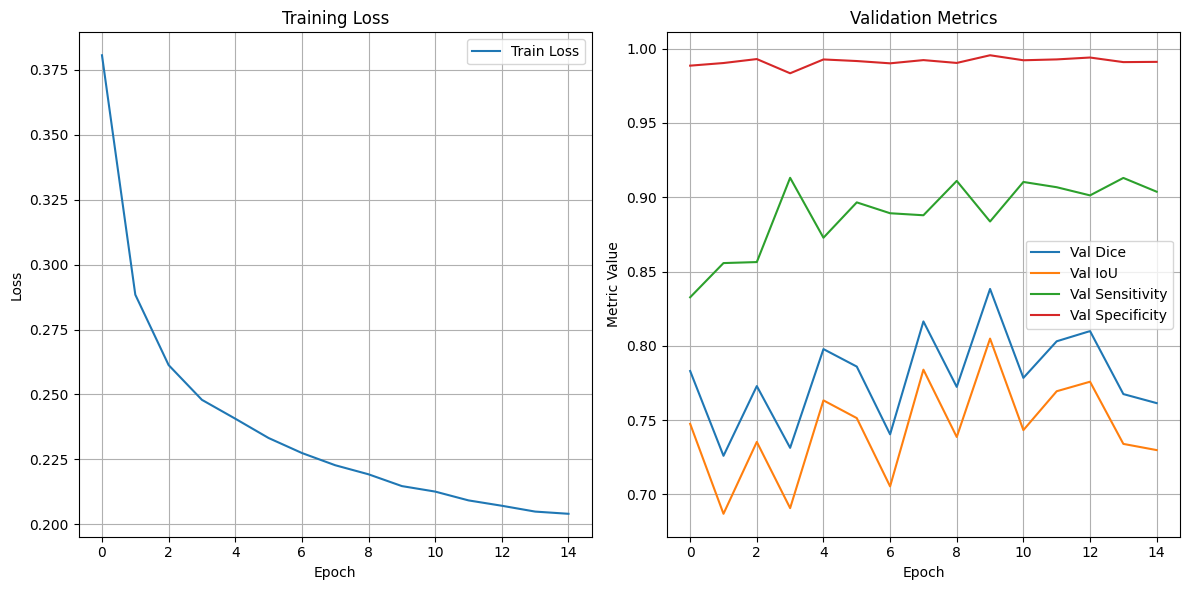

In [11]:
# Plot Training Curve
# =====================
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(val_dices, label="Val Dice")
plt.plot(val_ious, label="Val IoU")
plt.plot(val_sensitivities, label="Val Sensitivity")
plt.plot(val_specificities, label="Val Specificity")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("Validation Metrics")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [12]:
# Evaluation/Visualization Example
# =====================
def visualize_prediction(ct, gt_mask, pred_mask, idx=0, threshold=0.5):
    plt.figure(figsize=(12, 4))
    ct_img = ct[idx][0]
    gt = gt_mask[idx][0]
    pred = pred_mask[idx][0]
    pred_bin = (pred > threshold).astype(float)
    # Show CT
    plt.subplot(1, 3, 1)
    plt.imshow(ct_img, cmap='gray')
    plt.title("CT Image")
    # Show GT mask
    plt.subplot(1, 3, 2)
    plt.imshow(ct_img, cmap='gray')
    plt.imshow(gt, cmap='Reds', alpha=0.5)
    plt.title("Ground Truth")
    # Show Prediction
    plt.subplot(1, 3, 3)
    plt.imshow(ct_img, cmap='gray')
    plt.imshow(pred_bin, cmap='Blues', alpha=0.5)
    plt.title("Prediction (thresholded)")
    plt.tight_layout()
    plt.show()
    

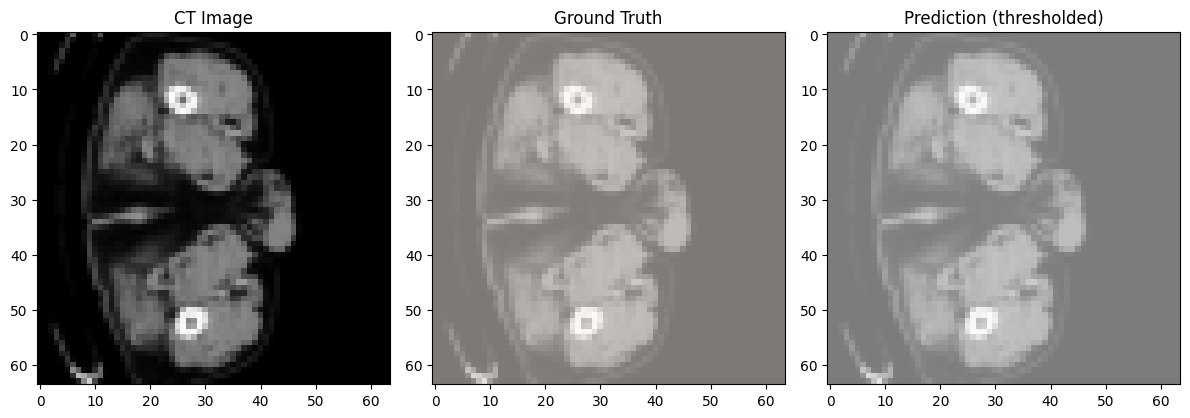

In [13]:
# Example from val loader
ct, mask = next(iter(val_loader))
output = torch.sigmoid(model(ct.to(device))).cpu().detach().numpy()
visualize_prediction(ct.numpy(), mask.numpy(), output, threshold=0.5)

In [14]:
# Save Model
# =====================
torch.save(model.state_dict(), "attention_unet_final.pth")